In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path.cwd().parent / "data"
BRANDS = ["Fresh", "Style", "Tech"]
COLOR = {"Fresh": "#2a78d6", "Style": "#eb6834", "Tech": "#1baf7a", "All": "#52514e"}
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "font.size": 10,
})

In [2]:
orders = pd.concat([pd.read_csv(DATA / "Training Data/deliveries_train.csv"),
                    pd.read_csv(DATA / "Test Data/task1_test_inputs.csv")], ignore_index=True)
orders["dow"] = pd.to_datetime(orders.order_date).dt.dayofweek
outlets = pd.read_csv(DATA / "General Data/outlets.csv")
fresh = orders[orders.brand == "Fresh"]
chilled = fresh[fresh.temp_requirement == "chilled"]
print(f"{len(orders):,} orders, {len(outlets)} outlets")

97,321 orders, 120 outlets


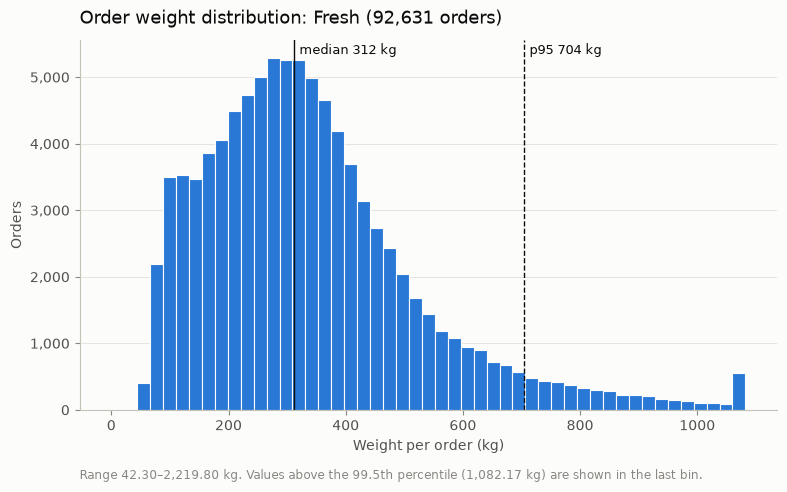

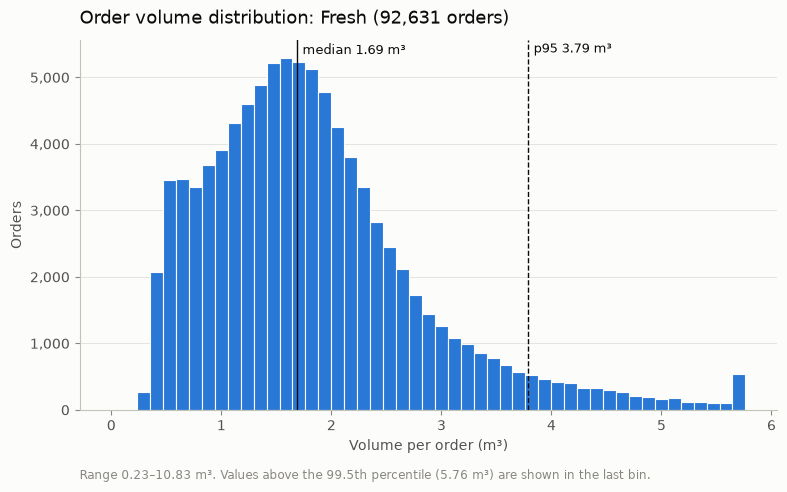

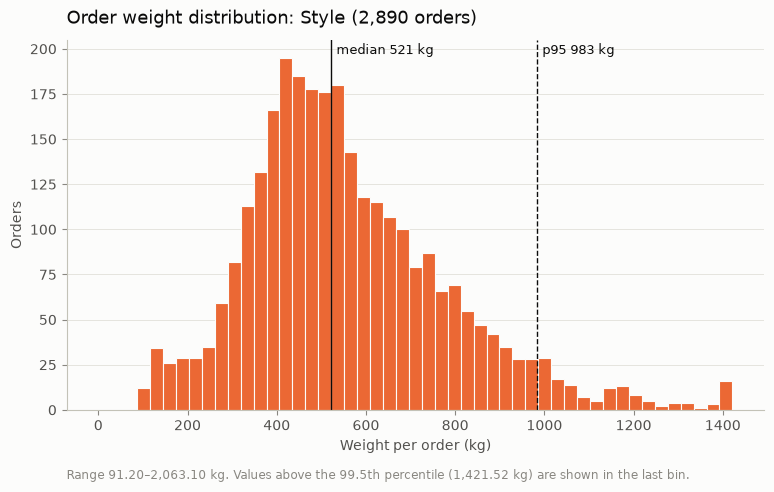

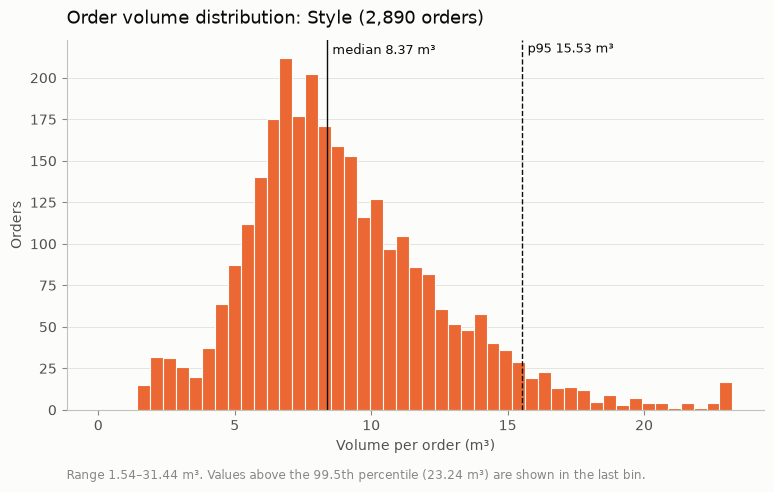

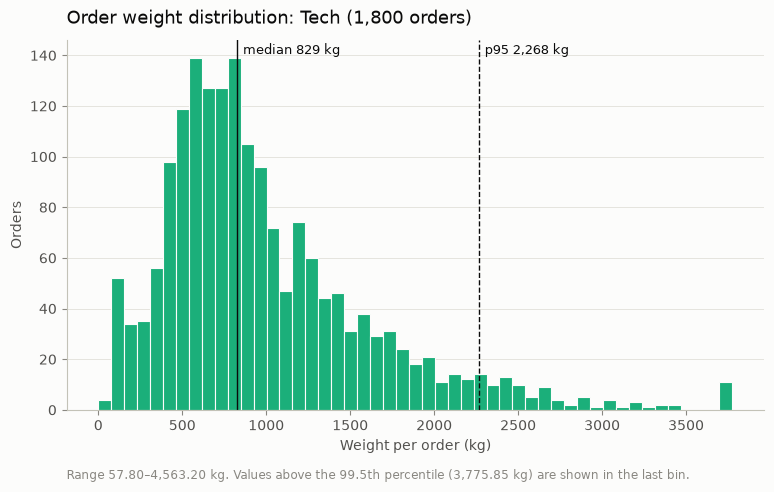

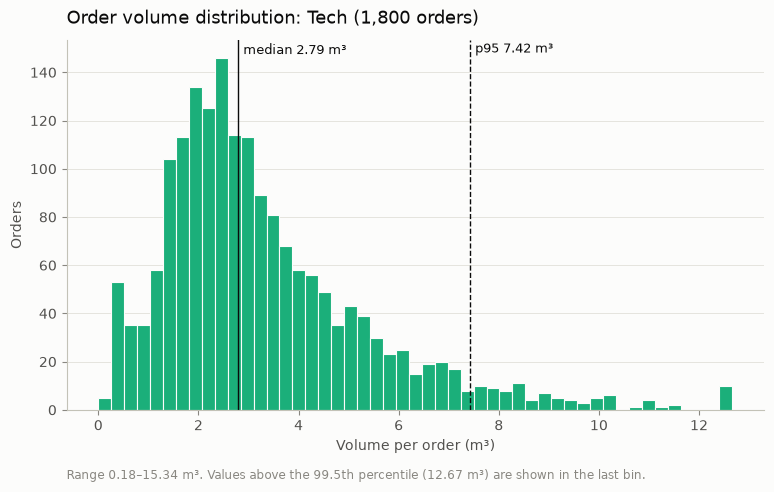

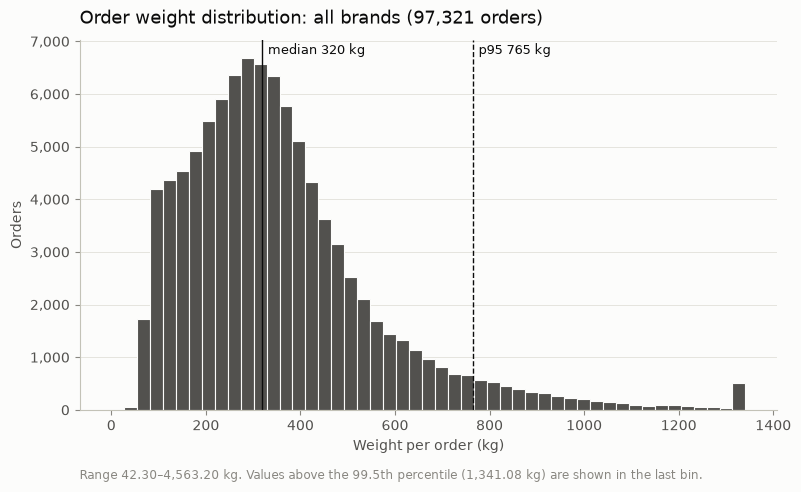

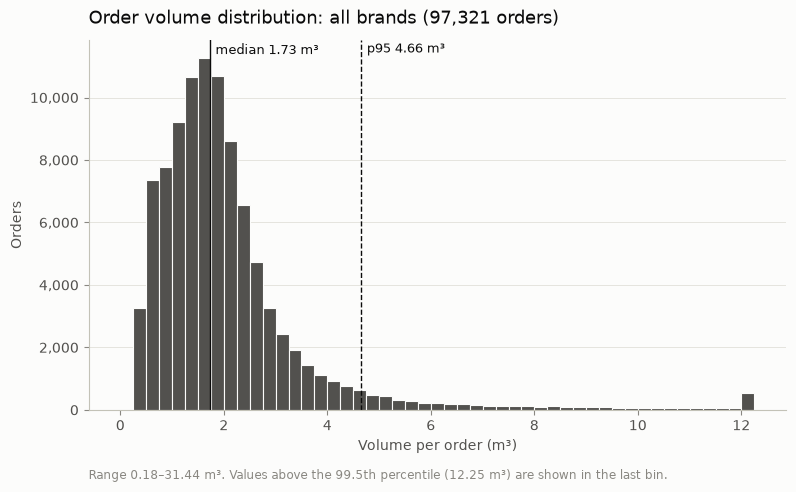

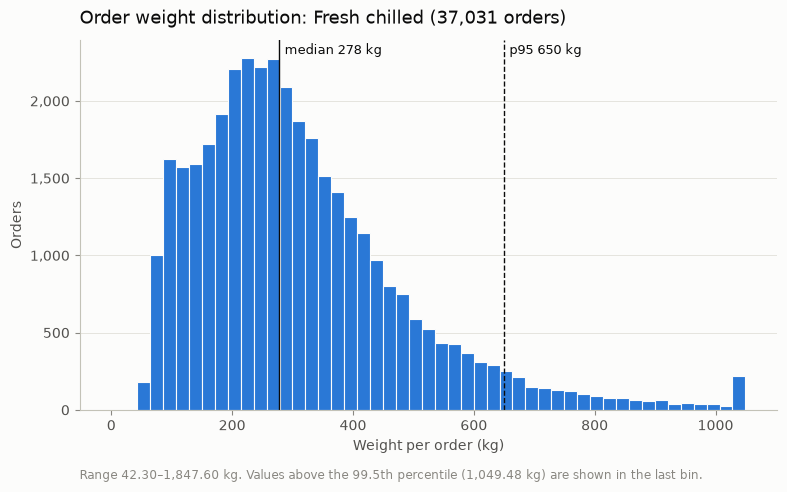

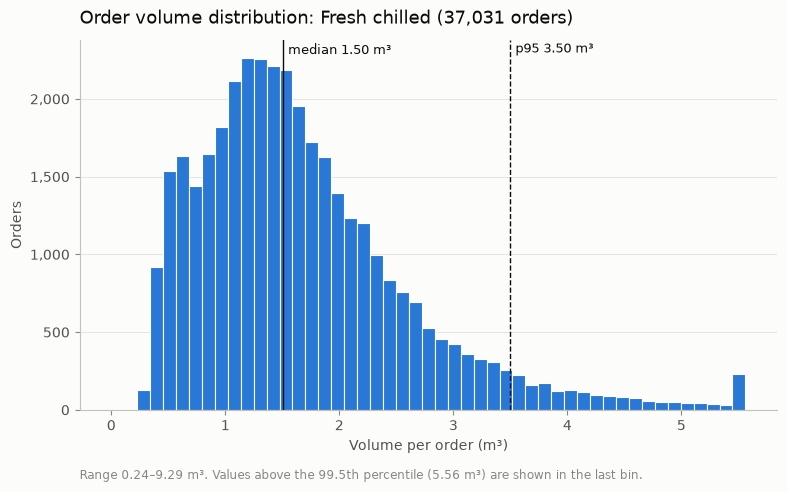

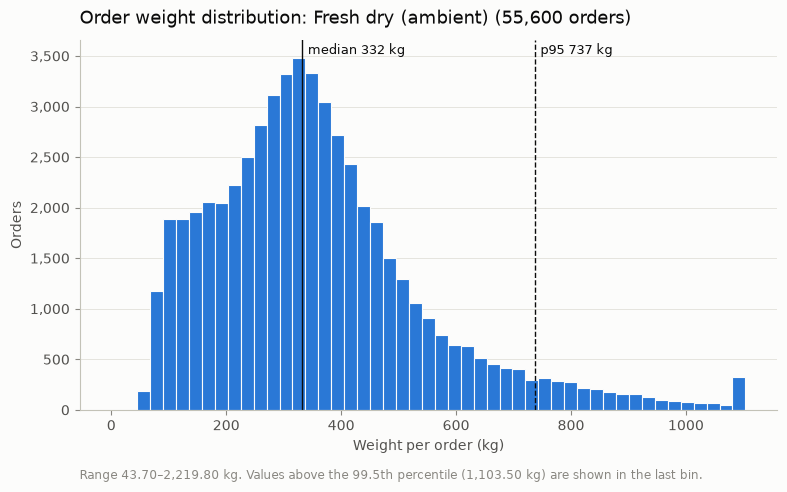

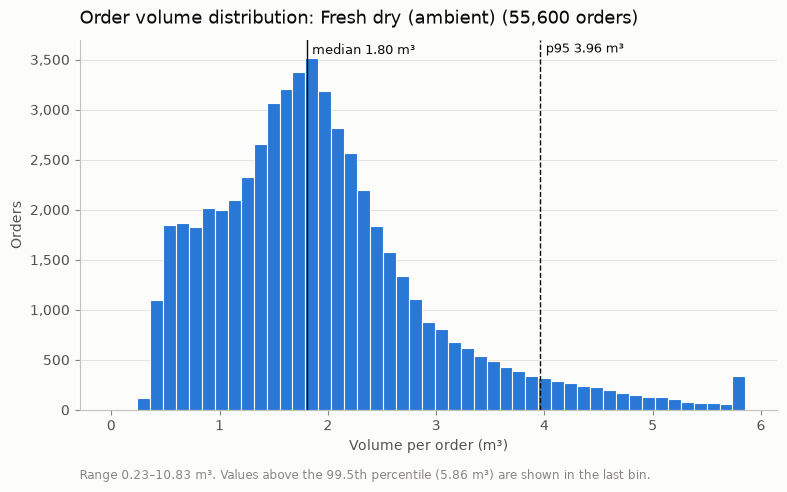

In [3]:
groups = [(who, "all brands" if who == "All" else who, orders if who == "All" else orders[orders.brand == who])
          for who in BRANDS + ["All"]]
groups += [("Fresh", "Fresh chilled", chilled), ("Fresh", "Fresh dry (ambient)", fresh[fresh.temp_requirement == "ambient"])]

for who, title, sub in groups:
    for column, unit, label in [("order_weight_kg", "kg", "weight"), ("order_volume_m3", "m³", "volume")]:
        values = sub[column]
        hi = np.percentile(values, 99.5)
        fig, ax = plt.subplots(figsize=(9, 4.8))
        ax.hist(values.clip(upper=hi), bins=np.linspace(0, hi, 50), color=COLOR[who], edgecolor=SURFACE, linewidth=0.8)
        ax.grid(axis="x", visible=False)
        for q, style in [(50, "-"), (95, "--")]:
            v = np.percentile(values, q)
            ax.axvline(v, color=INK, lw=1, ls=style)
            ax.annotate(f"{'median' if q == 50 else 'p95'} {v:,.{0 if unit == 'kg' else 2}f} {unit}",
                        (v, 1), xycoords=("data", "axes fraction"), xytext=(4, -2), textcoords="offset points",
                        fontsize=9, color=INK, va="top")
        ax.set_title(f"Order {label} distribution: {title} ({len(values):,} orders)")
        ax.set_xlabel(f"{label.capitalize()} per order ({unit})")
        ax.set_ylabel("Orders")
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
        ax.text(0, -0.16, f"Range {values.min():,.2f}–{values.max():,.2f} {unit}. Values above the 99.5th percentile "
                          f"({hi:,.2f} {unit}) are shown in the last bin.",
                transform=ax.transAxes, fontsize=8.5, color=MUTED, va="top")
        plt.show()

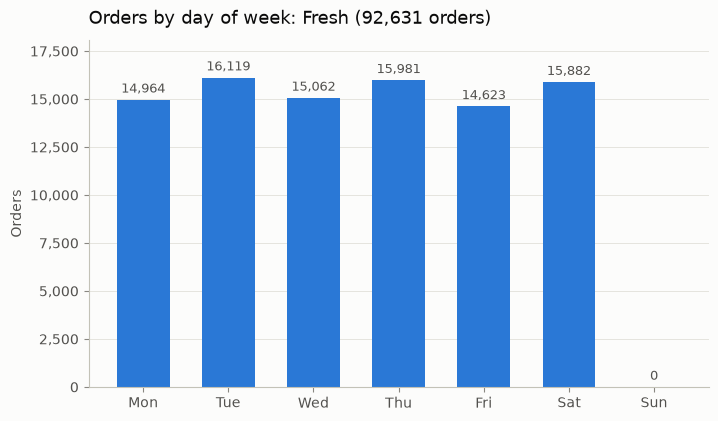

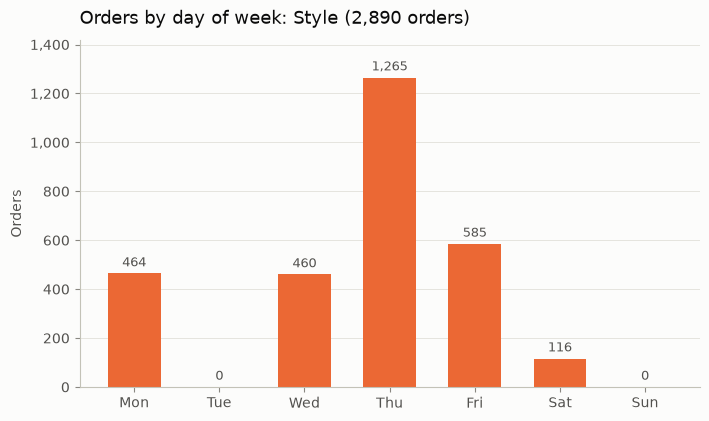

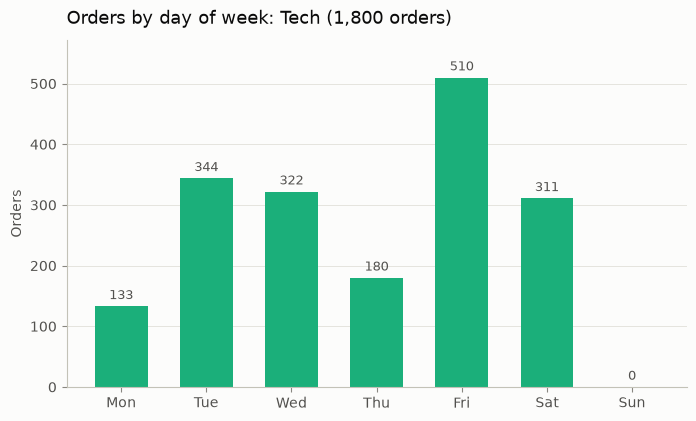

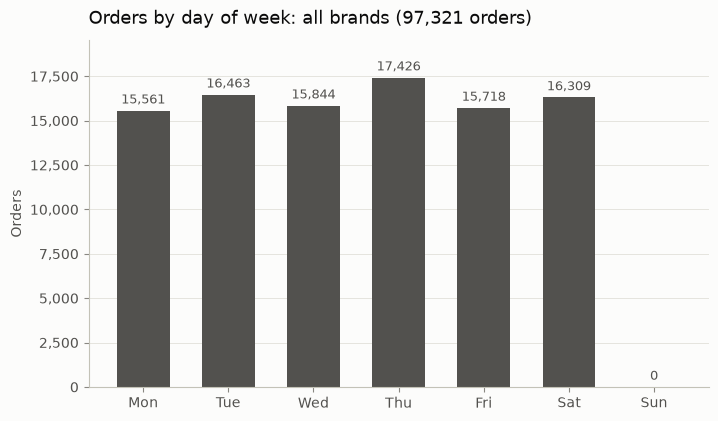

In [4]:
for who, title, sub in groups[:4]:
    counts = sub.groupby("dow").size().reindex(range(7), fill_value=0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(DAYS, counts.values, color=COLOR[who], width=0.62)
    ax.grid(axis="x", visible=False)
    ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3, fontsize=9, color=INK_2)
    ax.set_title(f"Orders by day of week: {title} ({len(sub):,} orders)")
    ax.set_ylabel("Orders")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    ax.margins(y=0.12)
    plt.show()

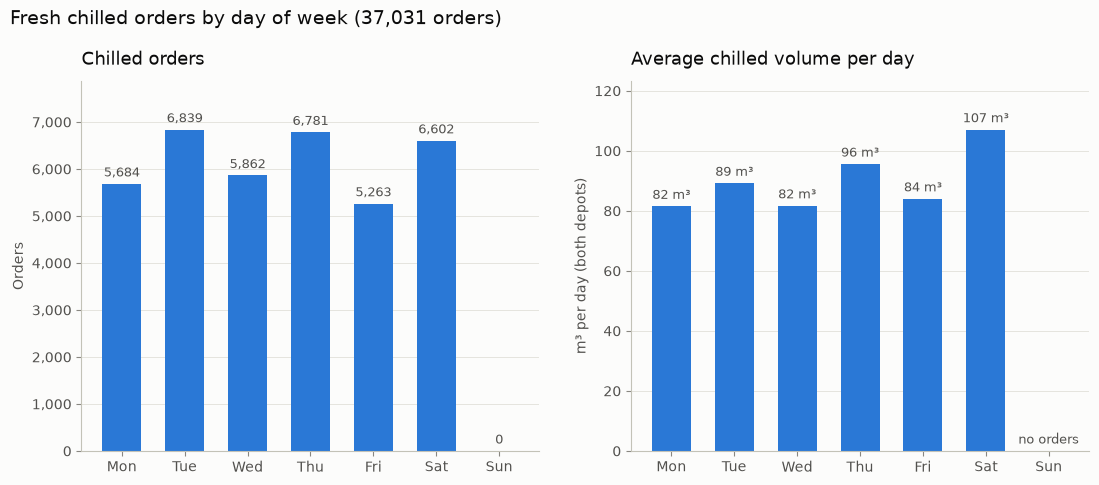

,orders,avg_daily_m3
Mon,5684,81.5
Tue,6839,89.2
Wed,5862,81.7
Thu,6781,95.6
Fri,5263,84.0
Sat,6602,107.1
Sun,0,NaN


In [5]:
counts = chilled.groupby("dow").size().reindex(range(7), fill_value=0)
daily = chilled.groupby(["order_date", "dow"]).order_volume_m3.sum().groupby("dow").mean().reindex(range(7))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(7)
bars = ax1.bar(x, counts.values, color=COLOR["Fresh"], width=0.62)
ax1.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3, fontsize=9.5, color=INK_2)
ax1.set_title("Chilled orders")
ax1.set_ylabel("Orders")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
bars = ax2.bar(x, daily.fillna(0).values, color=COLOR["Fresh"], width=0.62)
ax2.bar_label(bars, labels=[f"{v:.0f} m³" if v == v else "no orders" for v in daily.values],
              padding=3, fontsize=9.5, color=INK_2)
ax2.set_title("Average chilled volume per day")
ax2.set_ylabel("m³ per day (both depots)")
for ax in (ax1, ax2):
    ax.set_xticks(x, DAYS)
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.15)
fig.suptitle(f"Fresh chilled orders by day of week ({len(chilled):,} orders)", x=0.07, ha="left", fontsize=14, color=INK, y=1.03)
plt.show()
pd.DataFrame({"orders": counts, "avg_daily_m3": daily.round(1)}).set_axis(DAYS)

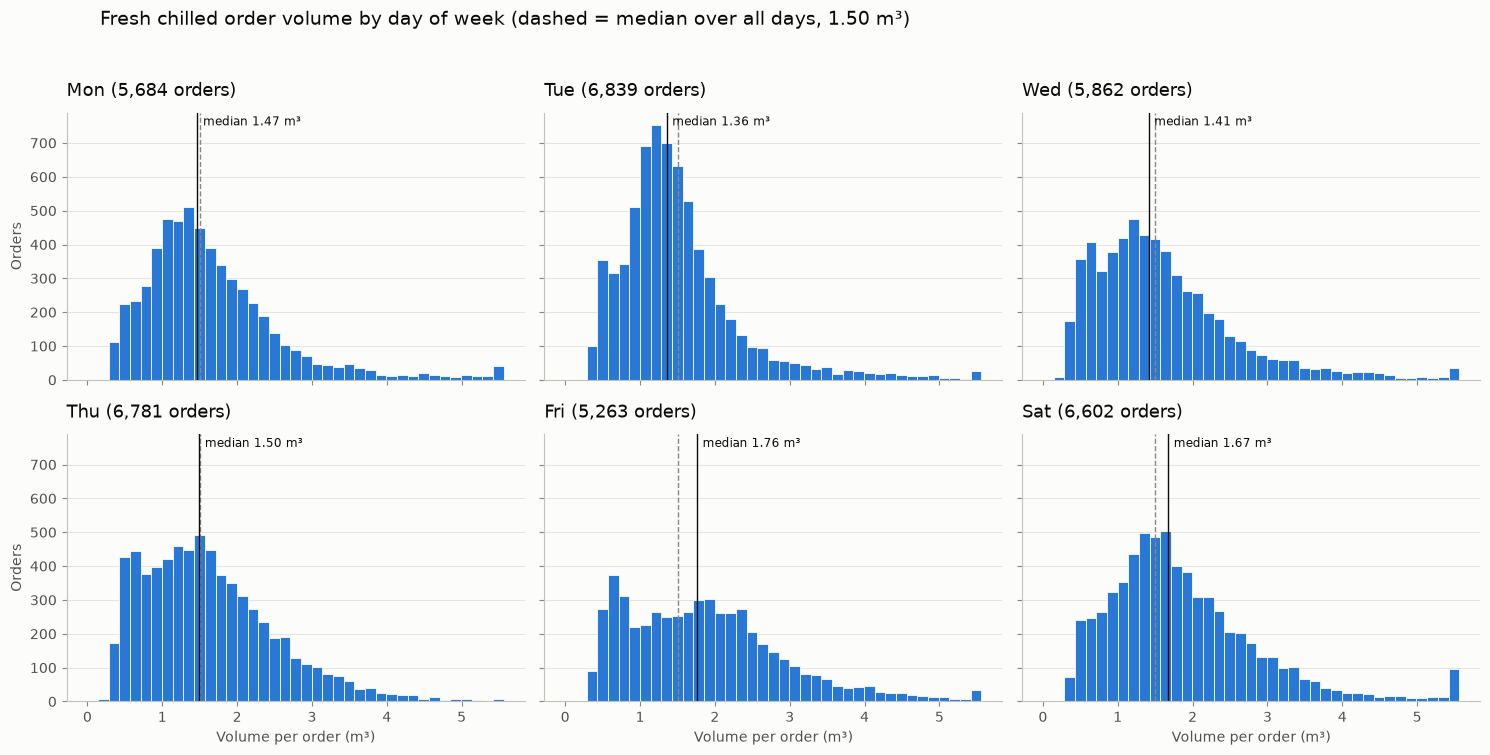

      count   mean    50%    95%
Mon  5684.0  1.664  1.470  3.462
Tue  6839.0  1.513  1.356  3.112
Wed  5862.0  1.603  1.412  3.458
Thu  6781.0  1.621  1.495  3.285
Fri  5263.0  1.868  1.762  3.885
Sat  6602.0  1.881  1.674  3.728


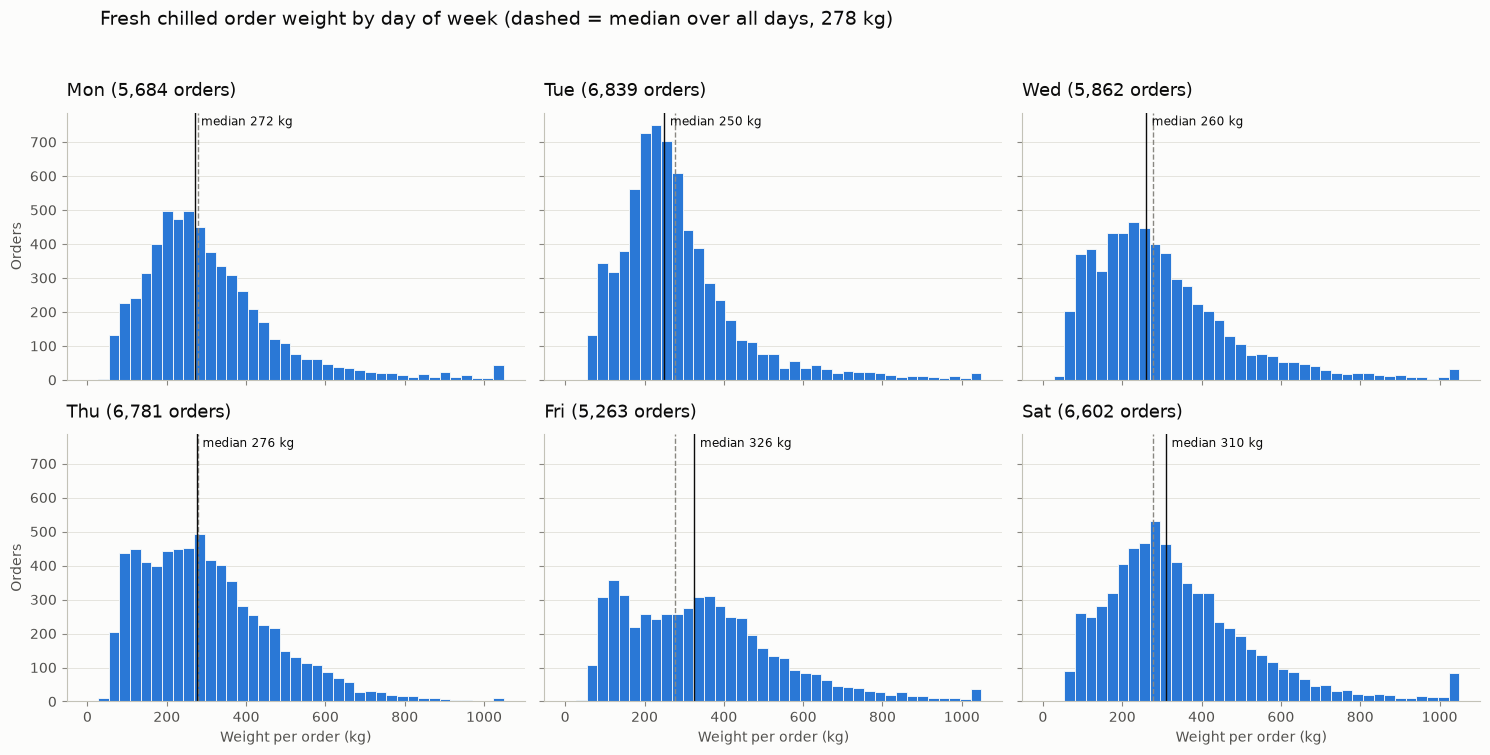

      count   mean    50%    95%
Mon  5684.0  308.6  272.4  642.5
Tue  6839.0  280.6  250.1  581.8
Wed  5862.0  297.0  260.1  646.0
Thu  6781.0  300.8  276.1  606.7
Fri  5263.0  346.2  325.8  718.2
Sat  6602.0  349.0  310.3  705.2


In [6]:
for column, unit, label in [("order_volume_m3", "m³", "volume"), ("order_weight_kg", "kg", "weight")]:
    hi = np.percentile(chilled[column], 99.5)
    bins = np.linspace(0, hi, 40)
    overall = chilled[column].median()
    dec = 0 if unit == "kg" else 2
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True, sharey=True)
    for d, ax in enumerate(axes.flat):
        vals = chilled.loc[chilled.dow == d, column]
        ax.hist(vals.clip(upper=hi), bins=bins, color=COLOR["Fresh"], edgecolor=SURFACE, linewidth=0.6)
        ax.axvline(overall, color=MUTED, lw=1, ls="--")
        med = vals.median()
        ax.axvline(med, color=INK, lw=1)
        ax.annotate(f"median {med:,.{dec}f} {unit}", (med, 1), xycoords=("data", "axes fraction"),
                    xytext=(4, -2), textcoords="offset points", fontsize=8.5, color=INK, va="top")
        ax.set_title(f"{DAYS[d]} ({len(vals):,} orders)")
        ax.grid(axis="x", visible=False)
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    for ax in axes[1]:
        ax.set_xlabel(f"{label.capitalize()} per order ({unit})")
    for ax in axes[:, 0]:
        ax.set_ylabel("Orders")
    fig.suptitle(f"Fresh chilled order {label} by day of week (dashed = median over all days, "
                 f"{overall:,.{dec}f} {unit})", x=0.07, ha="left", fontsize=14, color=INK, y=1.0)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
    print(chilled.groupby("dow")[column].describe(percentiles=[0.5, 0.95])[["count", "mean", "50%", "95%"]]
          .set_axis(DAYS[:6]).round(dec + 1))

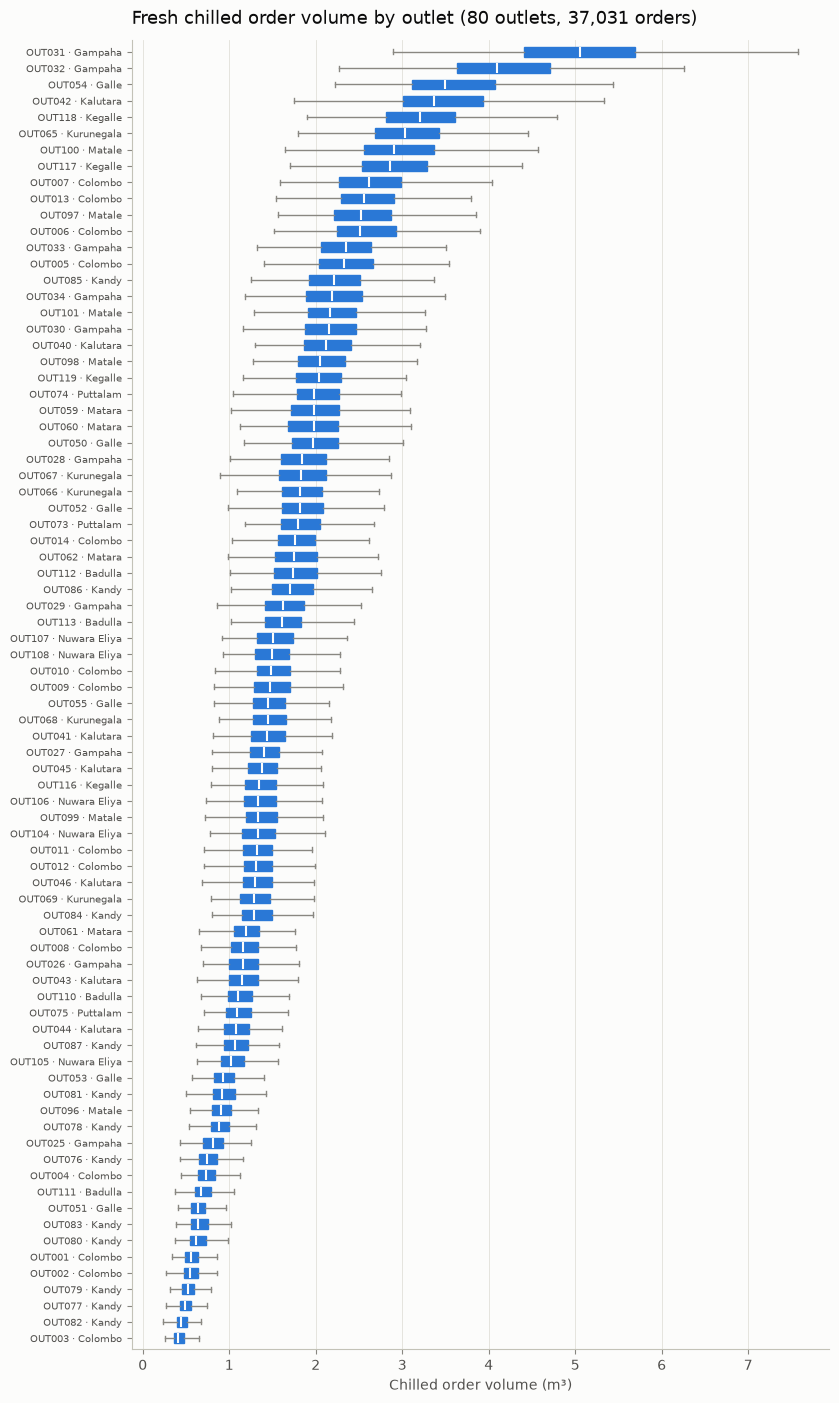

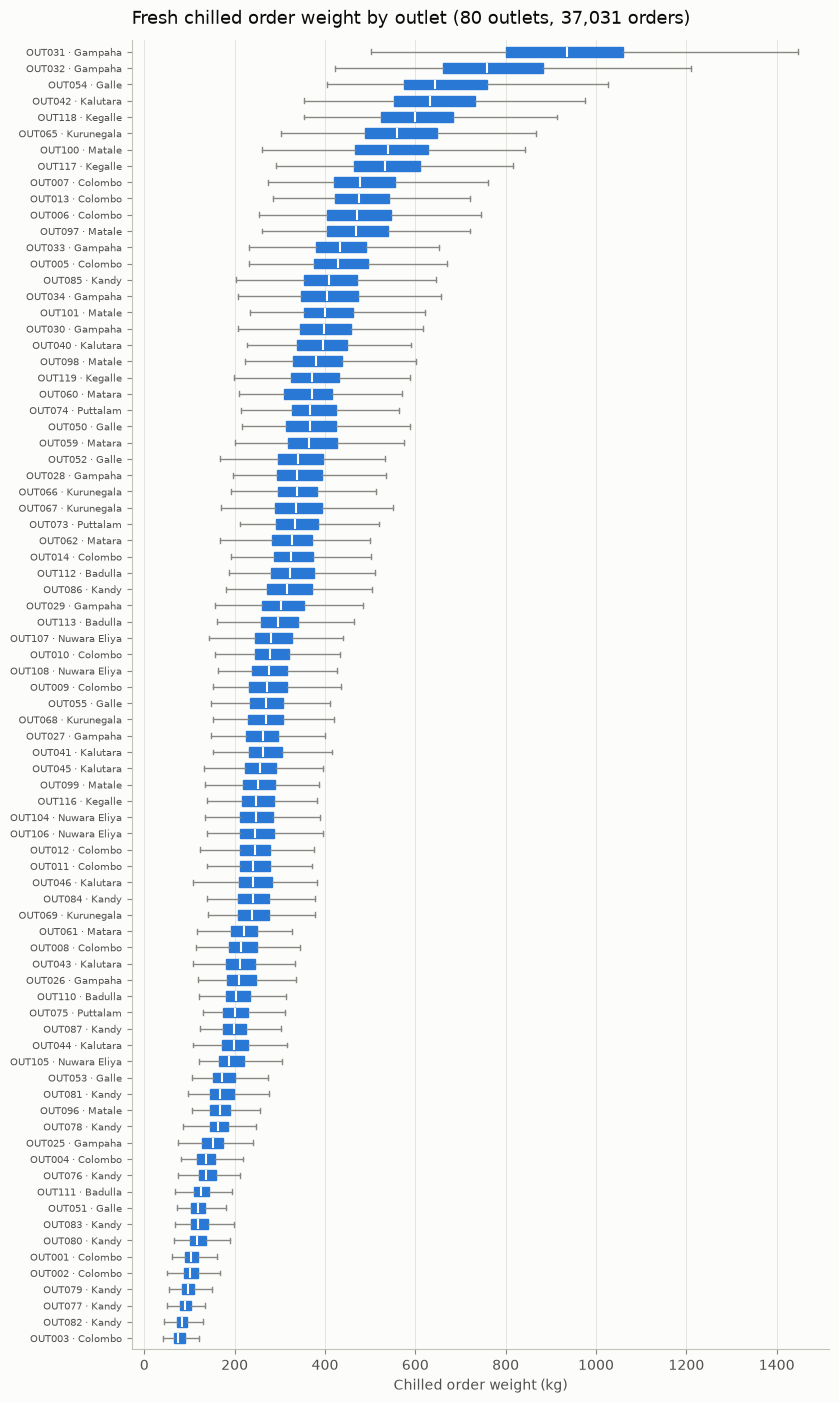

In [7]:
district = outlets.set_index("outlet_id").district
for column, unit, label in [("order_volume_m3", "m³", "volume"), ("order_weight_kg", "kg", "weight")]:
    order = chilled.groupby("outlet_id")[column].median().sort_values().index
    fig, ax = plt.subplots(figsize=(9, 17))
    ax.boxplot([chilled.loc[chilled.outlet_id == o, column].values for o in order], orientation="horizontal",
               widths=0.6, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=COLOR["Fresh"], edgecolor=COLOR["Fresh"]),
               medianprops=dict(color=SURFACE, linewidth=1.5),
               whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    ax.set_yticks(range(1, len(order) + 1), [f"{o} · {district[o]}" for o in order], fontsize=7.5)
    ax.set_ylim(0.3, len(order) + 0.7)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(f"Chilled order {label} ({unit})")
    ax.set_title(f"Fresh chilled order {label} by outlet ({len(order)} outlets, {len(chilled):,} orders)")
    plt.show()

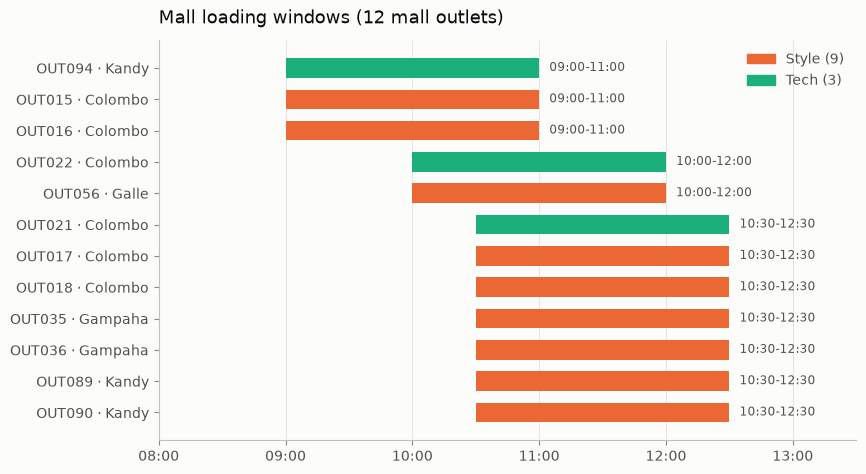

mall_window
09:00-11:00    3
10:00-12:00    2
10:30-12:30    7
Name: count, dtype: int64

In [8]:
to_hours = lambda s: int(s[:2]) + int(s[3:]) / 60
mall = outlets[outlets.mall_window.notna()].copy()
mall["start"], mall["end"] = mall.window_open_time.map(to_hours), mall.window_close_time.map(to_hours)
mall = mall.sort_values(["start", "brand", "outlet_id"], ascending=[False, True, False])
fig, ax = plt.subplots(figsize=(9, 5.2))
y = np.arange(len(mall))
ax.barh(y, mall.end - mall.start, left=mall.start, color=[COLOR[b] for b in mall.brand], height=0.62)
ax.set_yticks(y, [f"{r.outlet_id} · {r.district}" for r in mall.itertuples()])
ax.set_xlim(8, 13.5)
ax.set_xticks(range(8, 14), [f"{h:02d}:00" for h in range(8, 14)])
ax.grid(axis="y", visible=False)
for yi, r in zip(y, mall.itertuples()):
    ax.text(r.end + 0.08, yi, r.mall_window, va="center", fontsize=8.5, color=INK_2)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR[b]) for b in ["Style", "Tech"]], ["Style (9)", "Tech (3)"],
          frameon=False, loc="upper right", labelcolor=INK_2)
ax.set_title("Mall loading windows (12 mall outlets)")
plt.show()
mall.mall_window.value_counts().sort_index()

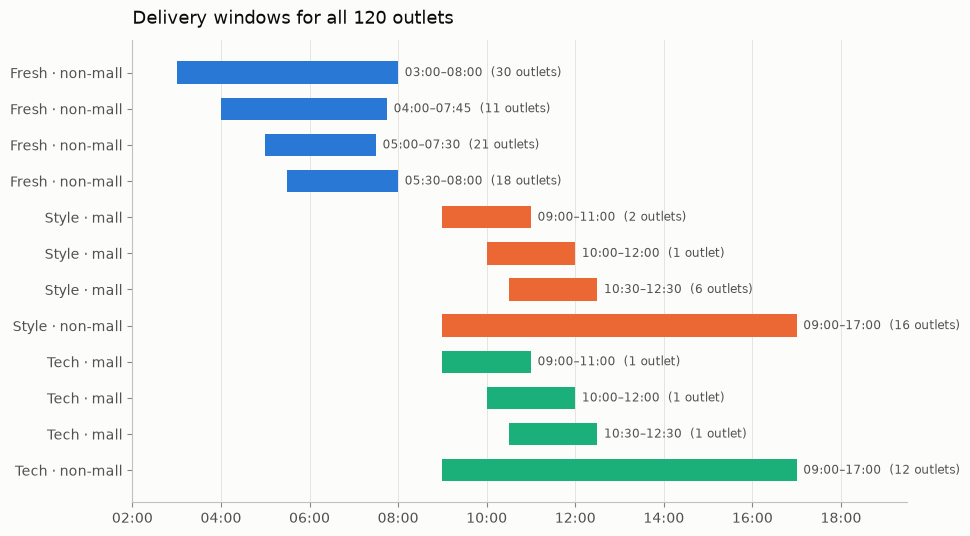

In [9]:
g = (outlets.assign(kind=np.where(outlets.mall_window.notna(), "mall", "non-mall"))
     .groupby(["brand", "kind", "window_open_time", "window_close_time"]).size().reset_index(name="n"))
g["start"], g["end"] = g.window_open_time.map(to_hours), g.window_close_time.map(to_hours)
g = g.sort_values(["brand", "kind", "start", "end"], ascending=[False, False, False, False])
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(g))
ax.barh(y, g.end - g.start, left=g.start, color=[COLOR[b] for b in g.brand], height=0.62)
ax.set_yticks(y, [f"{r.brand} · {r.kind}" for r in g.itertuples()])
ax.set_xlim(2, 19.5)
ax.set_xticks(range(2, 20, 2), [f"{h:02d}:00" for h in range(2, 20, 2)])
ax.grid(axis="y", visible=False)
for yi, r in zip(y, g.itertuples()):
    ax.text(r.end + 0.15, yi, f"{r.window_open_time}–{r.window_close_time}  ({r.n} outlet{'s' * (r.n > 1)})",
            va="center", fontsize=8.5, color=INK_2)
ax.set_title("Delivery windows for all 120 outlets")
plt.show()